### Imports

In [1]:
from datetime import date
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Define timeframe for stock data

In [2]:
end = date.today()
start = end.replace(
    year=end.year - 3,
    day = min(end.day, 28) if end.month == 2 else end.day
)

start_date = start.strftime("%Y-%m-%d")
end_date = end.strftime("%Y-%m-%d")

### Fetch and clean stock data

In [3]:
def get_stock_data(ticker):
    data = yf.download(ticker, start_date, end_date)
    return data

df = get_stock_data("NVDA")
df.reset_index(inplace=True)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2023-03-23,27.166946,27.474675,26.666390,27.091013,564889000
1,2023-03-24,26.755316,27.142973,26.331691,27.007094,454920000
2,2023-03-27,26.507536,26.976121,26.341682,26.813265,361026000
3,2023-03-28,26.386642,26.489552,25.827138,26.423610,356104000
4,2023-03-29,26.960133,27.054049,26.573476,26.801275,393694000


### Plot stock data

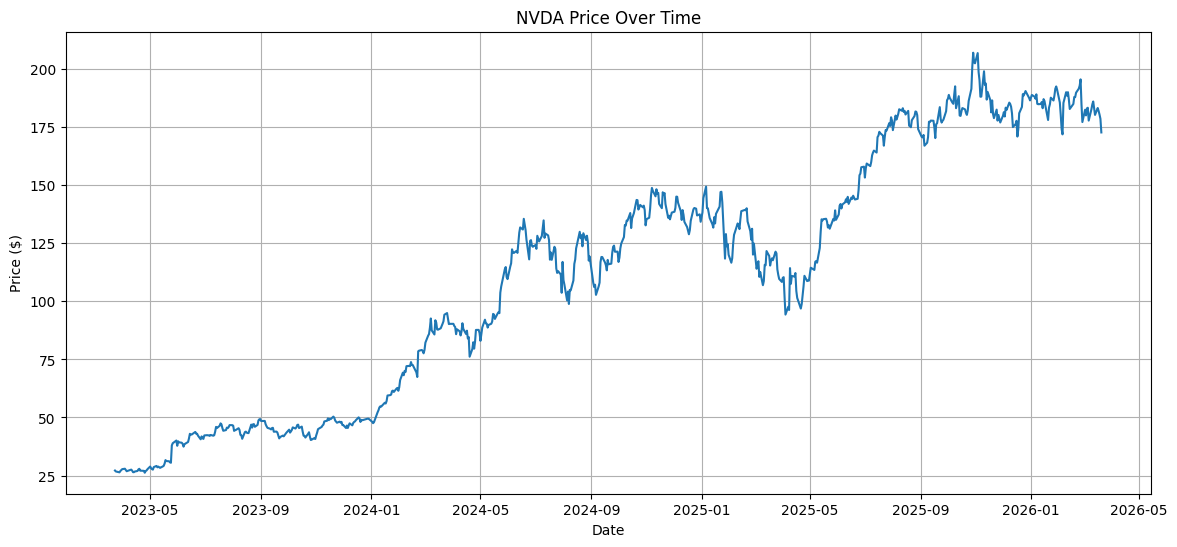

In [4]:
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("NVDA Price Over Time")
plt.show()

### Plot the 9, 21, and 100 EMAs

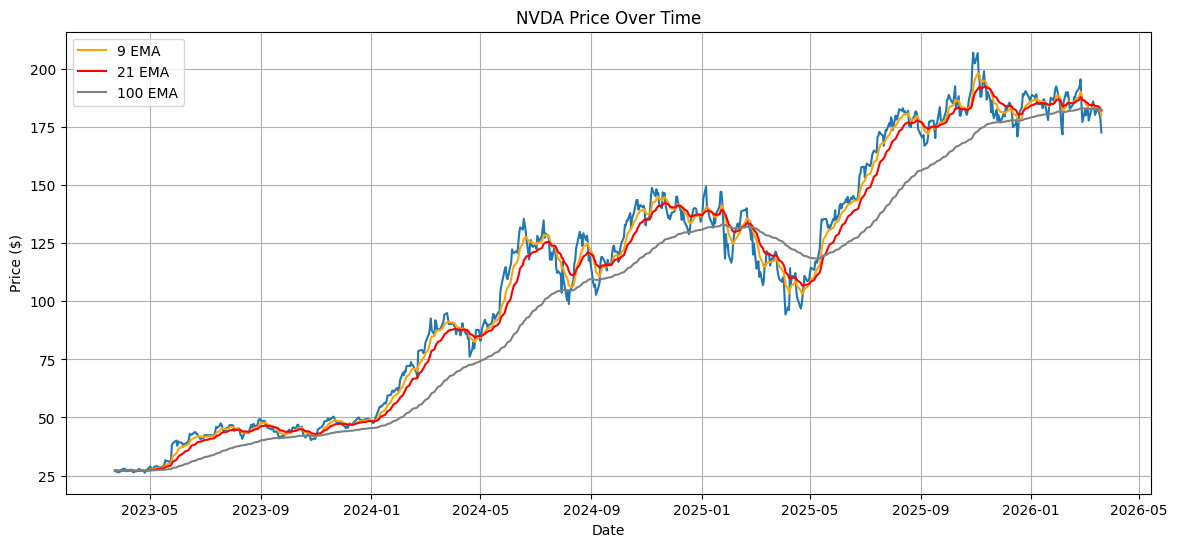

In [5]:
# Calculate EMAs
df["ema9"] = df["Close"].ewm(span=9, adjust=False).mean()
df["ema21"] = df["Close"].ewm(span=21, adjust=False).mean()
df["ema100"] = df["Close"].ewm(span=100, adjust=False).mean()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("NVDA Price Over Time")

# Plot EMAs
plt.plot(df["Date"], df["ema9"], label="9 EMA", color="orange")
plt.plot(df["Date"], df["ema21"], label="21 EMA", color="red")
plt.plot(df["Date"], df["ema100"], label="100 EMA", color="gray")
plt.legend()

### Use a 70/30 train/test split

In [6]:
df.shape

(751, 9)

In [7]:
split = int(len(df) * 0.7)
train = df[:split]
test = df[split:]

In [8]:
print(train.shape)
train.head()

(525, 9)


,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100
0,2023-03-23,27.166946,27.474675,26.666390,27.091013,564889000,27.166946,27.166946,27.166946
1,2023-03-24,26.755316,27.142973,26.331691,27.007094,454920000,27.084620,27.129525,27.158795
2,2023-03-27,26.507536,26.976121,26.341682,26.813265,361026000,26.969203,27.072981,27.145899
3,2023-03-28,26.386642,26.489552,25.827138,26.423610,356104000,26.852691,27.010587,27.130864
4,2023-03-29,26.960133,27.054049,26.573476,26.801275,393694000,26.874179,27.006000,27.127483


In [9]:
print(test.shape)
test.head()

(226, 9)


,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100
525,2025-04-28,108.704384,110.343997,105.995016,109.664157,207708500,106.004816,107.232321,119.325016
526,2025-04-29,108.994316,110.174038,107.414694,107.644636,170444300,106.602716,107.392503,119.120447
527,2025-04-30,108.894333,108.894333,104.055477,104.445385,235044600,107.061039,107.529033,118.917950
528,2025-05-01,111.583702,114.912919,111.273778,113.053357,236121500,107.965572,107.897639,118.772718
529,2025-05-02,114.473030,115.372820,113.343299,114.153106,190194800,109.267063,108.495402,118.687575


### Normalize the dataset

In [10]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler has default param feature_range=(0,1)
scaler = MinMaxScaler()

train_close = train[["Close"]]
test_close = test[["Close"]]

# Scale training data
train_close_scaled = scaler.fit_transform(train_close)

# Scale testing data
prev_100_close = train_close.tail(100)
test_close = pd.concat([prev_100_close, test_close], ignore_index=True)
test_close_scaled = scaler.transform(test_close)

In [11]:
train_close_scaled[:10]

array([[0.00770649],
       [0.00436433],
       [0.00235253],
       [0.00137096],
       [0.0060273 ],
       [0.00926407],
       [0.01246022],
       [0.01398528],
       [0.00983192],
       [0.00519177]])

In [12]:
test_close_scaled[:10]

array([[0.90917878],
       [0.91226279],
       [0.9254921 ],
       [0.96509861],
       [0.96453045],
       [0.94326485],
       [0.91380127],
       [0.88344506],
       [0.91785956],
       [0.90186972]])

### Create training sequences

In [13]:
x_train = []
y_train = []

# For each price x, grab the 100 prices before it and add them as a singular (list) element to x_train. Add price x as an element to y_train.
for i in range(100, train_close_scaled.shape[0]):
    x_train.append(train_close_scaled[i - 100 : i])
    y_train.append(train_close_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)
print(y_train.shape)

(425, 100, 1)
(425,)


### Create testing sequences

In [14]:
x_test = []
y_test = []

for i in range(100, test_close_scaled.shape[0]):
    x_test.append(test_close_scaled[i - 100 : i])
    y_test.append(test_close_scaled[i, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)

print(x_test.shape)
print(y_test.shape)

(226, 100, 1)
(226,)


### Build LSTM model

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

In [16]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1], 1)))

model.add(LSTM(units=50, activation="relu", return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation="relu", return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation="relu", return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(units=1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

### Train model

In [17]:
import tensorflow as tf

In [18]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

model.fit(x_train, y_train, epochs=100)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.2171 - mean_absolute_error: 0.3847
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0514 - mean_absolute_error: 0.1900
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0316 - mean_absolute_error: 0.1488
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0245 - mean_absolute_error: 0.1273
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0218 - mean_absolute_error: 0.1134
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0170 - mean_absolute_error: 0.0994
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0184 - mean_absolute_error: 0.1024
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0173 - mean_absolute_error: 0.0984
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0161 - mean_absolute_error: 0.0937
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0154 - mean_absolute_error: 0.0890
Epoch 11/100
14/14 ━━━━━━━━━━

### Make prediction

In [19]:
y_pred = model.predict(x_test)
print(y_pred.shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
(226, 1)


In [20]:
print(y_test[:10])

[0.6697338  0.67208785 0.67127606 0.69311187 0.7165712  0.71105137
 0.70877854 0.73735171 0.73986818 0.73402357]


In [21]:
print(y_pred[:10])

[[0.6459583 ]
 [0.6456178 ]
 [0.64727294]
 [0.6504921 ]
 [0.655083  ]
 [0.661142  ]
 [0.6683284 ]
 [0.67603385]
 [0.6841889 ]
 [0.692624  ]]


### Plot prediction

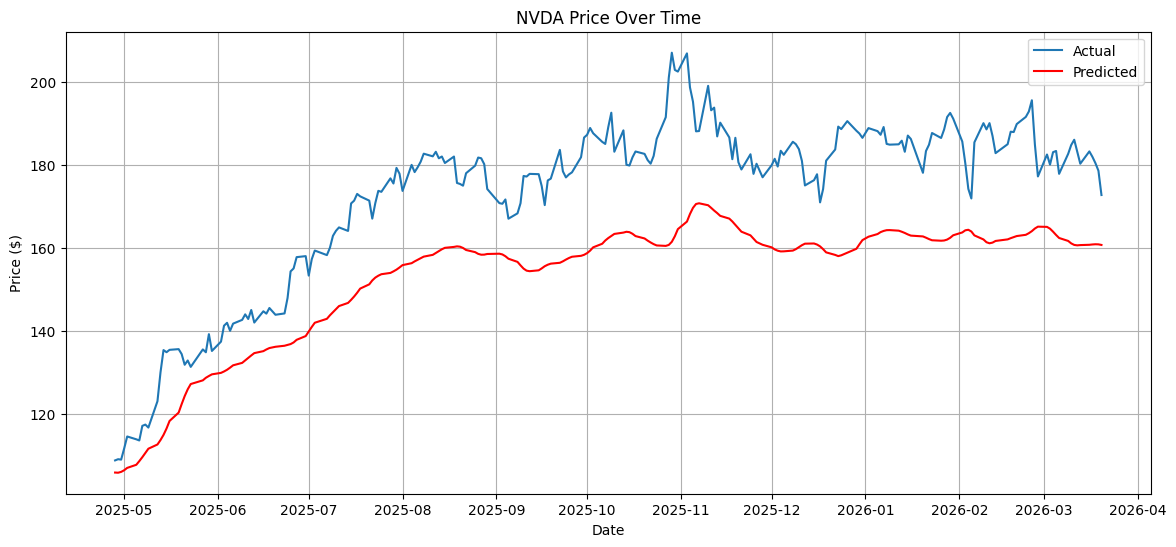

In [22]:
y_pred_prices = scaler.inverse_transform(y_pred)
y_test_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(test["Date"], y_test_prices, label="Actual")
plt.plot(test["Date"], y_pred_prices, label="Predicted", color="red")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("NVDA Price Over Time")
plt.legend()